<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Support_Vector_Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 5 - 9.6.1 Support Vector Classifiers
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [ ]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix

from mlxtend.plotting import plot_decision_regions

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#set seed
np.random.seed(1)
X = np.random.normal(size = (20,2))
y = np.array([0]*10 + [1]*10)  #maked an array which has ten 0, and ten 1

X[y==1,] = X[y==1,] + 1 #here, we are adding 1 to all the observations where y = 1
# The reason is to make the classes more separable than before

In [ ]:
#making a dataframe
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})
df.head()

,X1,X2,y
0,1.624345,-0.611756,0
1,-0.528172,-1.072969,0
2,0.865408,-2.301539,0
3,1.744812,-0.761207,0
4,0.319039,-0.249370,0


<Axes: xlabel='X1', ylabel='X2'>

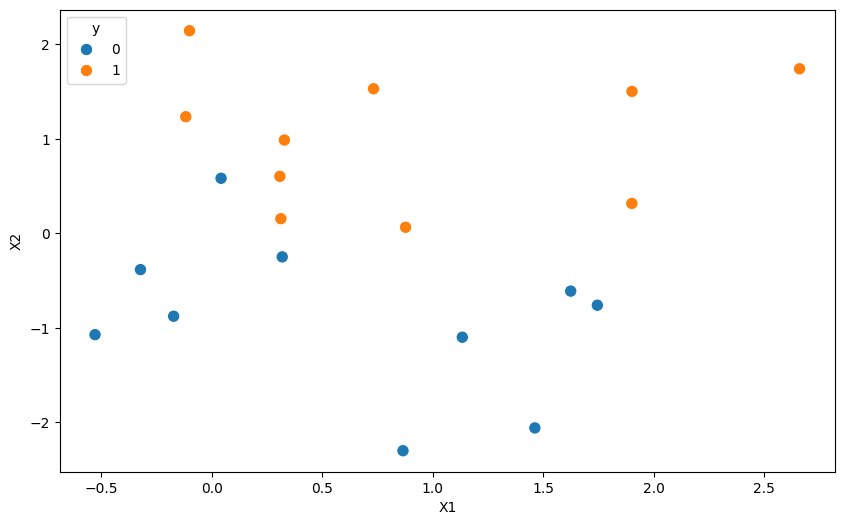

In [ ]:
plt.figure(figsize = (10,6))
#sns.scatterplot(df['X1'],df['X2'],hue = df['y'],s = 80) this line of code does not work anymore

sns.scatterplot(data = df ,x = "X1",y = "X2",hue = "y", s = 80) # s controls the size of the points


Just as we were expecting (from the text), the data is not linearly separable into two classes

## Fitting the svm and visualizing the results

In [ ]:
svm = SVC(kernel='linear',C = 10)
svm.fit(df.drop('y',axis = 1),df['y'])

SVC(C=10, kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

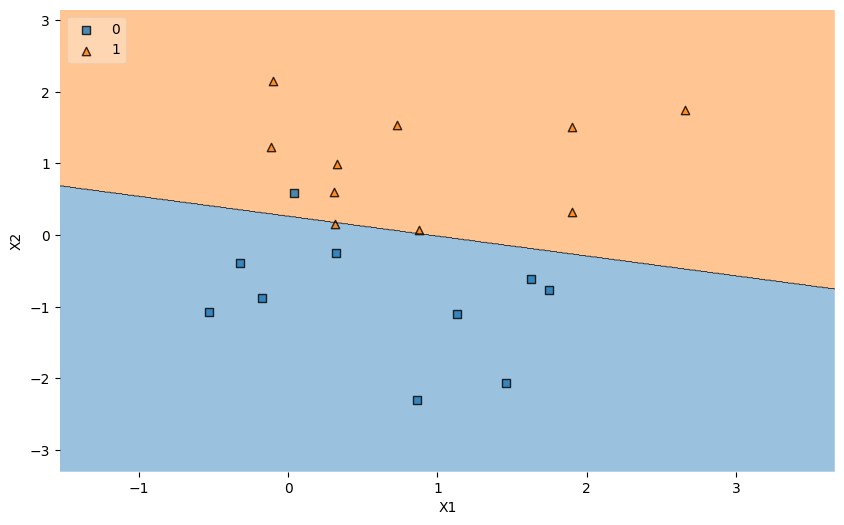

In [ ]:
# for plotting decision boundary i have used mlxtend library
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


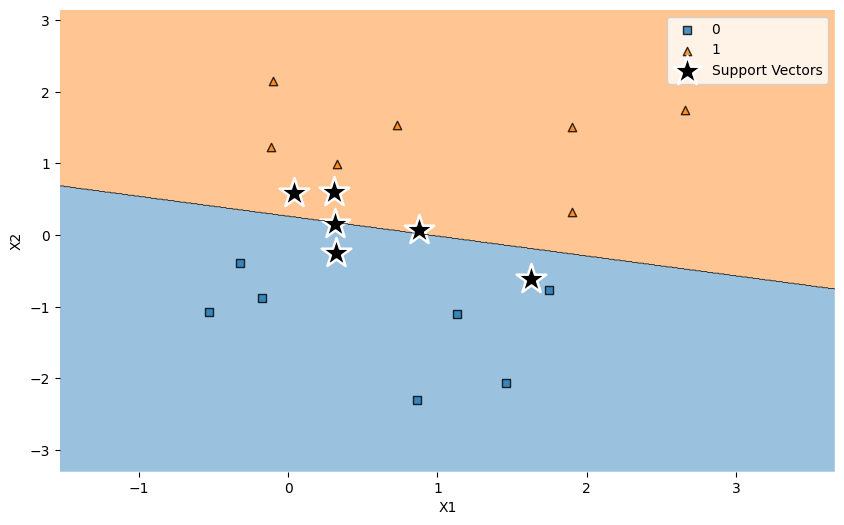

In [ ]:
# adding support vectors to the graph
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)
sns.scatterplot(x = svm.support_vectors_[:,0], y = svm.support_vectors_[:,1],marker='*',s = 500,color = 'black',label = 'Support Vectors')

plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()

## Using a lower value of C.

Lets see what different we will have when we use a lower value of the paramter C

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

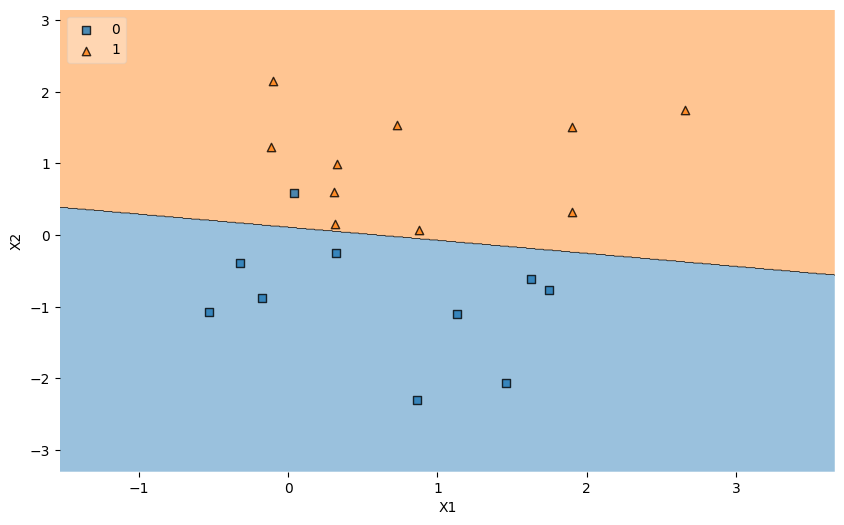

In [ ]:
svm = SVC(kernel='linear',C = 1)
svm.fit(df.drop('y',axis = 1),df['y'])

# for plotting decision boundary i have used mlxtend library
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


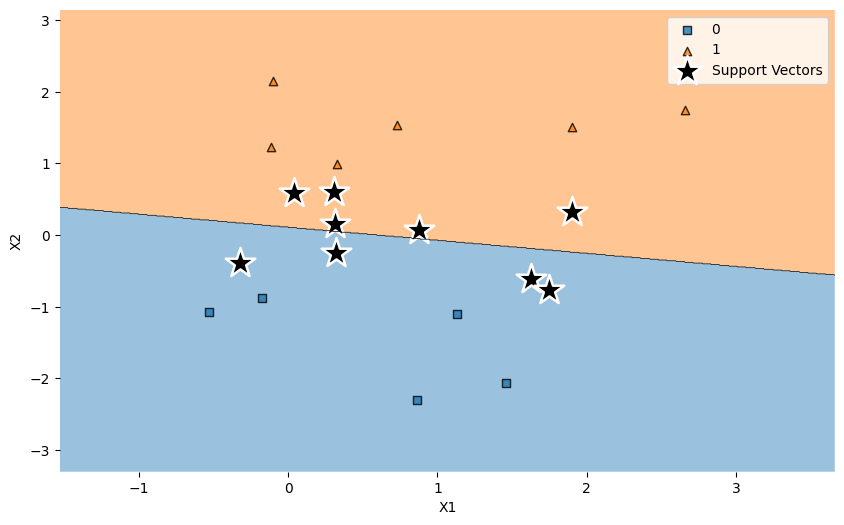

In [ ]:
# adding support vectors to the graph
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)
sns.scatterplot(x = svm.support_vectors_[:,0], y = svm.support_vectors_[:,1],marker='*',s = 500,color = 'black',label = 'Support Vectors')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()

We can see that now we have more number of support vectors as compared to the last time.

## Using cross validation to select the best value of C

For this i will be using gridsearchCV

In [ ]:
svm = SVC(kernel='linear')
search = GridSearchCV(svm,{'C':[0.001, 0.01, 0.1, 1,5,10,100]},cv=10)
search.fit(df.drop('y',axis=1),df['y'])

GridSearchCV(cv=10, estimator=SVC(kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]})

In [ ]:
search.best_params_

{'C': 0.001}

In [ ]:
best_model = search.best_estimator_

## Checking the performance of the best model on test data

For that lets first of all create a test data

In [ ]:
np.random.seed(1)
X_test = np.random.normal(size = (20,2))
y_test = np.array([0]*10 + [1]*10)  #maked an array which has ten 0, and ten 1

X_test[y_test==1,] = X_test[y_test==1,] + 1
df_test = pd.DataFrame({'X1':X_test[:,0],'X2':X_test[:,1],'y':y_test})

In [ ]:
#lets see the accuracy and confusion matrix on test data by best_model
preds = best_model.predict(df_test.drop('y',axis=1))
print('Accuracy score is ',accuracy_score(y_test,preds))

print('Confusion Matrix is -')
confusion_matrix(y_test,preds)

Accuracy score is  0.95
Confusion Matrix is -


array([[ 9,  1],
       [ 0, 10]])

## Using the case where the classes are linearily separable (barely)

In [ ]:
#set seed
np.random.seed(1)
X = np.random.normal(size = (20,2))
y = np.array([0]*10 + [1]*10)  #maked an array which has ten 0, and ten 1

X[y==1,] = X[y==1,] + 1.4
# The reason is to make the classes more separable than before

In [ ]:
#making a dataframe
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})
df.head()

,X1,X2,y
0,1.624345,-0.611756,0
1,-0.528172,-1.072969,0
2,0.865408,-2.301539,0
3,1.744812,-0.761207,0
4,0.319039,-0.249370,0


<Axes: xlabel='X1', ylabel='X2'>

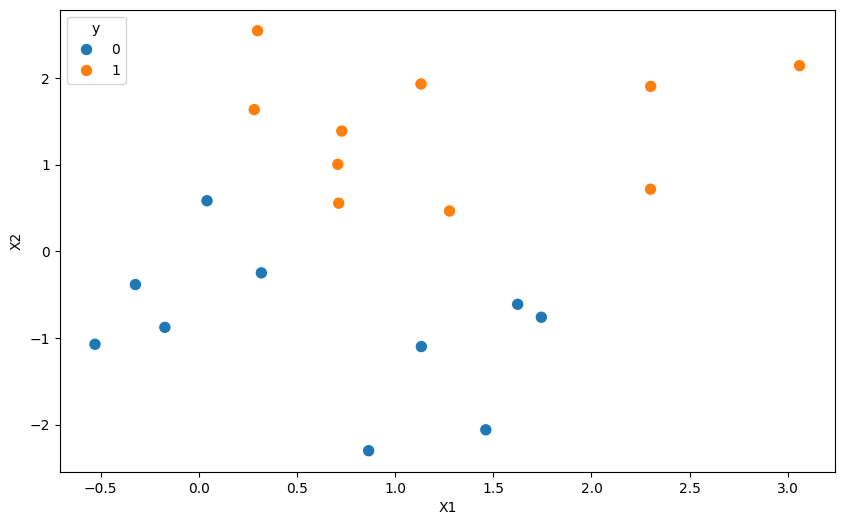

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df ,x = "X1",y = "X2",hue = "y", s = 80) # s controls the size of the points

In [ ]:
#using a very high value of C
svm = SVC(kernel='linear',C = 10000)
svm.fit(df.drop('y',axis = 1),df['y'])

SVC(C=10000, kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

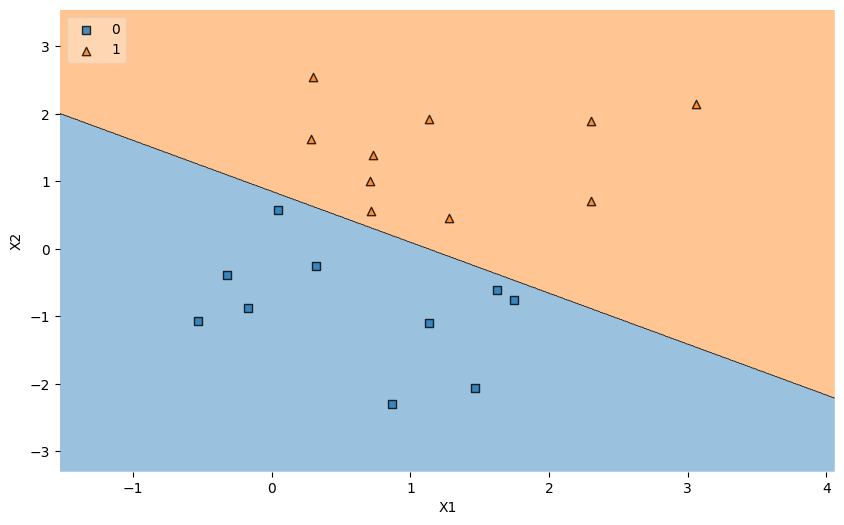

In [ ]:
# for plotting decision boundary i have used mlxtend library
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

### Using smaller value of cost on this data

In [ ]:
#using a very small value of C
svm = SVC(kernel='linear',C = 1)
svm.fit(df.drop('y',axis = 1),df['y'])

SVC(C=1, kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

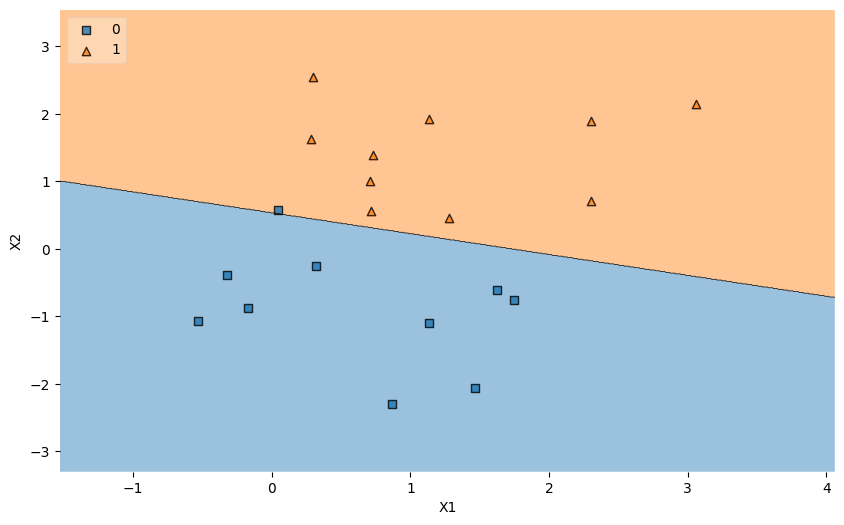

In [ ]:
# for plotting decision boundary i have used mlxtend library
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(df.drop('y',axis=1)), np.array(df['y']), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

We can see that one observation is misclassified when using C = 1, however there were no misclassifications when C was large